<a href="https://colab.research.google.com/github/vahabi9918/Practice/blob/main/SimpleLinearRegression0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [85]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [86]:
df = pd.read_csv('/content/drive/MyDrive/Python-Basics/height-weight.csv')

In [87]:
df.head()

,Weight,Height
0,45,120
1,58,135
2,48,123
3,60,145
4,70,160


Text(0, 0.5, 'Height')

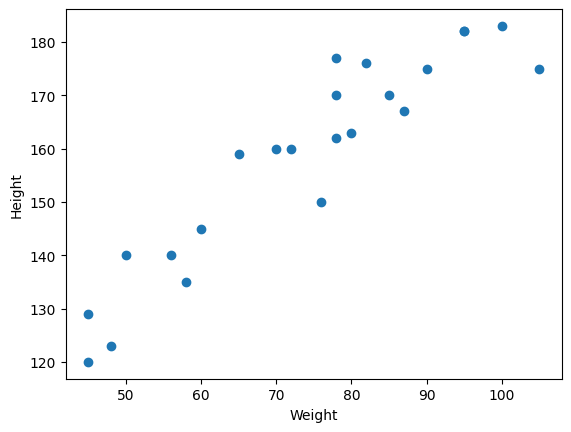

In [88]:
plt.scatter(df['Weight'],df['Height'])
plt.xlabel('Weight')
plt.ylabel('Height')

In [89]:
X = df[['Weight']]
y = df['Height']

In [90]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size = 0.20, random_state = 42)

In [91]:
X.shape

(23, 1)

In [92]:
X_train.shape,X_test.shape,y_train.shape,y_test.shape

((18, 1), (5, 1), (18,), (5,))

In [93]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

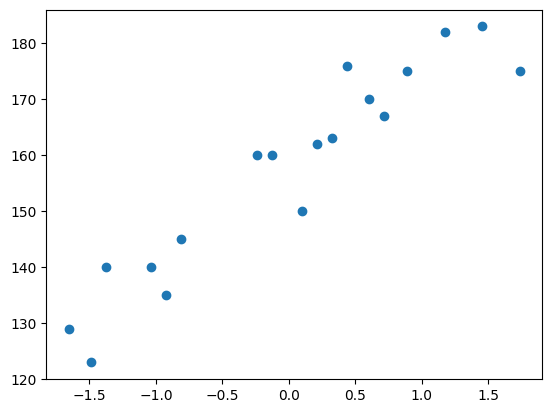

In [94]:
plt.scatter(X_train, y_train)

In [95]:
from sklearn.linear_model import LinearRegression
regressor = LinearRegression()
regressor.fit(X_train, y_train)

LinearRegression()

In [96]:
print("the slope of weight is: ",regressor.coef_)
print("intersept: ",regressor.intercept_)

the slope of weight is:  [17.03440872]
intersept:  157.5


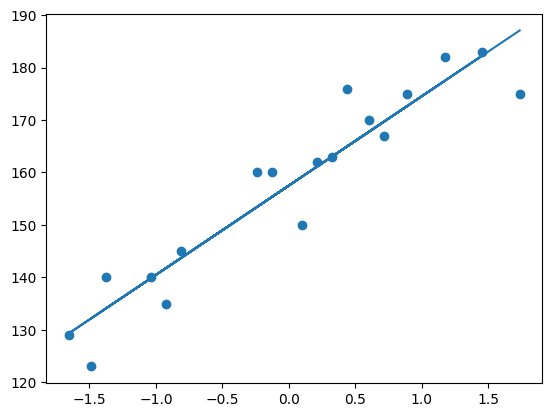

In [97]:
plt.scatter(X_train, y_train)
plt.plot(X_train, regressor.predict(X_train))

In [98]:
y_pred_test = regressor.predict(X_test_scaled)

In [99]:
y_pred_test,y_test

(array([161.08467086, 161.08467086, 129.3041561 , 177.45645118,
        148.56507414]),
 15    177
 9     170
 0     120
 8     182
 17    159
 Name: Height, dtype: int64)

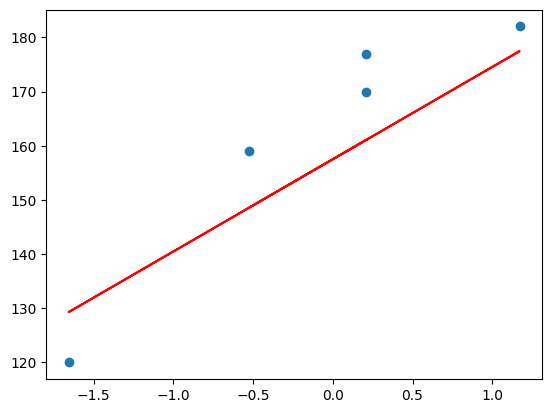

In [100]:
plt.scatter(X_test_scaled,y_test)
plt.plot(X_test_scaled,regressor.predict(X_test_scaled),'r')

In [101]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
mse = mean_squared_error(y_test, y_pred_test)
mae = mean_absolute_error(y_test, y_pred_test)
rmse = np.sqrt(mse)
print(mse)
print(mae)
print(rmse)

109.77592599051664
9.822657814519232
10.477400726827081


In [102]:
from sklearn.metrics import r2_score
score = r2_score(y_test, y_pred_test)

In [103]:
score

0.776986986042344

In [104]:
#adjusted R-squared
1-(1-score)*(len(y_test)-1)/(len(y_test)-X_test.shape[1]-1)

0.7026493147231252

In [105]:
scaled_weight = scaler.transform([[80]])
scaled_weight

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([[0.32350772]])

In [106]:
regressor.predict([scaled_weight[0]])

array([163.01076266])